__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Introduction
The goal of this file is to demonstrate the limitations of the integral parameter estimation used to calculate insulin sensitivity $S_I$

# Setup
## Patient Cohort
+ 50 patients
+ Simulation over 60 hours
+ Initial $BG$ (mmol/L) is chosen from a log normal distribution of $\mu = 7.6$ and $\sigma=1.3$
+ Initial $Q$ and $I$ is 15 mu/L
+ Inital $P1$ and $P2$ is assumed to be 0 mmol/L
+ $\,SI$ for the patients will be set constant at $2 \cdot 10^{-4}$ 
+ $u_{ex}(t) = 75 \cdot e^{-\left(\frac{\log(2)}{300}\right) \cdot \left((t + 120) \mod (300)\right)}$ (mU/min)
+ $\,PN(t) = e^{-\left(\frac{\log(2)}{300}\right) \cdot \left(t \mod (300)\right)}$ (mmol/min)
+ $D(t) = 0.30$ (mmol/min)
+ True dynamics are derived from the ICING model with time steps $\,dt=1$ min
+ Blood Glucose measurements occur every 2 hours that contain Gaussian measurement noise $N(0,\sigma^2)$
    + $\sigma$ will range from $\begin{bmatrix*}0.0 & 0.25 & 0.5 & 0.75 & 1.0 \end{bmatrix*}$

# Experiment
+ For each patient and the respective $\sigma$, insulin sensitivity will be fitted hourly
+ The Absolute Relative Difference will be used as the error metric

In [2]:
try:
    SI_est_error_01 = np.load("../scripts/variables/SI_est_error_01.npy")
    meas_noise_std = np.load("../scripts/variables/meas_noise_std_01.npy")
    print("Loaded variables")
except Exception:
    print('Run 01_Integral_Estimation_script.py')

Loaded variables


# Plot Results

+ The MARD (95% CI) error will be plotted along for each measurement noise std $\sigma$

In [3]:
mean_err = np.mean(SI_est_error_01, axis=1)
ci_low = np.percentile(SI_est_error_01, 2.5, axis=1)
ci_high = np.percentile(SI_est_error_01, 97.5, axis=1)
time = 60*np.arange(mean_err.shape[1])

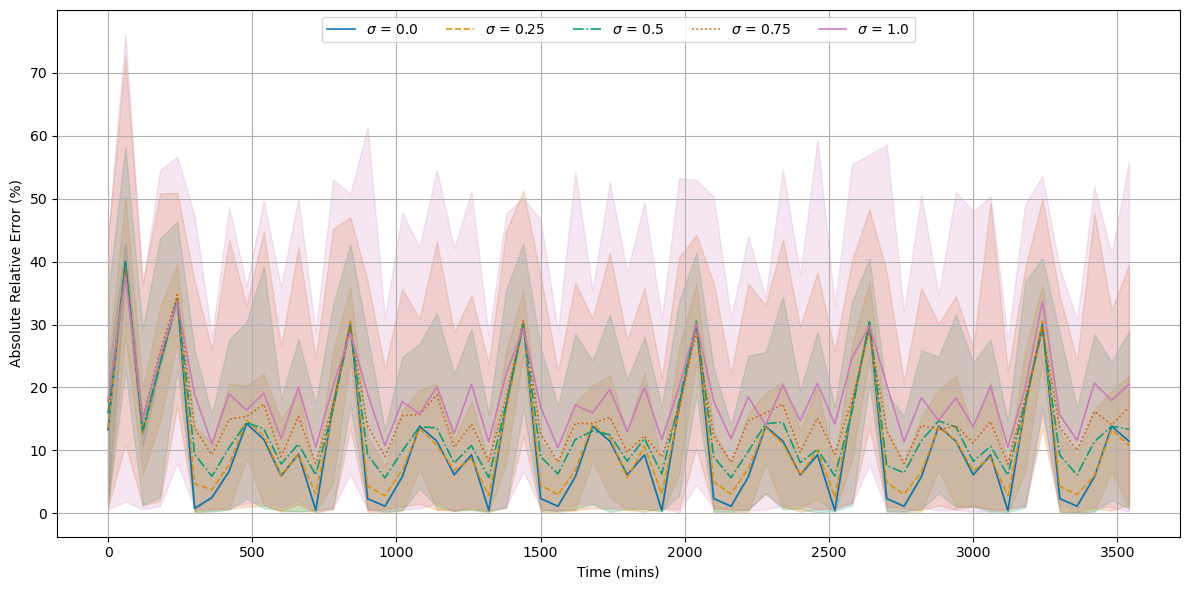

In [4]:
num_plots = mean_err.shape[0]
palette = sns.color_palette("colorblind", num_plots)

fig, ax = plt.subplots(figsize=(12,6))
for i in range(num_plots):
    ax.plot(time, mean_err[i,:], color=palette[i], linewidth=1.2, alpha=0.95, linestyle = ['-', '--', '-.', ':'][i % 4], label = f"$\\sigma$ = {meas_noise_std[i]}")
    ax.fill_between(time, ci_low[i,:], ci_high[i,:], color=palette[i], alpha=0.18)
    ax.set_ylabel('Absolute Relative Error (%)')

ax.legend(loc='upper center', ncols=num_plots)
ax.set_xlabel('Time (mins)')
ax.grid()
fig.tight_layout()